Melhores parâmetros: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Melhor F1-Score (treino): 92.88%

--- Random Forest ---
Acurácia: 95.20%
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        94
           1       1.00      0.81      0.89        31

    accuracy                           0.95       125
   macro avg       0.97      0.90      0.93       125
weighted avg       0.95      0.95      0.95       125



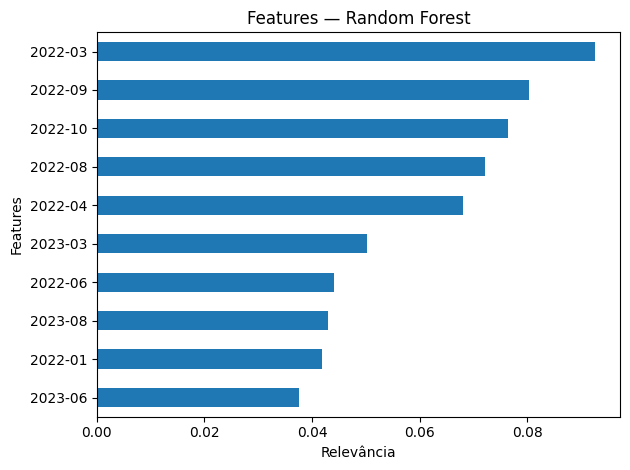

Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Melhor F1-Score (treino): 91.32%

--- XGBoost ---
Acurácia: 96.00%
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        94
           1       0.96      0.87      0.92        31

    accuracy                           0.96       125
   macro avg       0.96      0.93      0.94       125
weighted avg       0.96      0.96      0.96       125



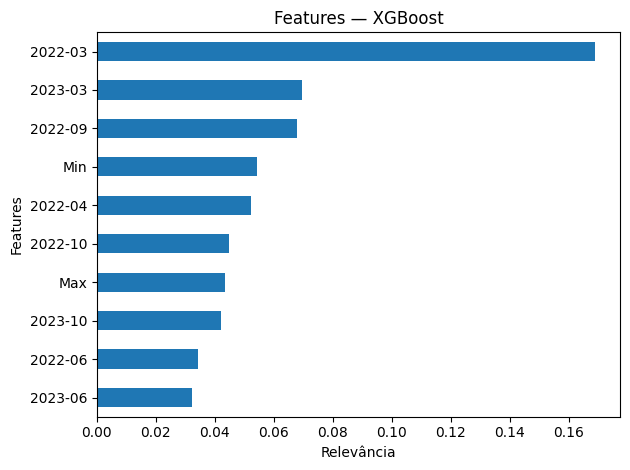

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from configs.constants import RANDOM_STATE, TEST_SIZE
from configs.paths import ESTATISTICAS_CLASSIFICACOES
from dados.carregamento import carregar_dados, juntar_acervos_com_estatisticas
from dados.preprocessamento import preparar_features
from modelos.random_forest import treinar_random_forest
from modelos.xgboost import treinar_xgboost
from utils.avaliacao import avaliar_modelo
from utils.visualizacao import plotar_feature_importance
                         


# carregar e preparar os dados
acervos, colunas_meses = carregar_dados()

# merge com estatísticas geradas pela EDA
estatisticas = pd.read_csv(ESTATISTICAS_CLASSIFICACOES)
df = juntar_acervos_com_estatisticas(acervos, estatisticas)

X, y = preparar_features(df, colunas_meses)

# dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# treinar e avaliar Random Forest e XGBoost
rf = treinar_random_forest(X_train, y_train)
avaliar_modelo(rf, X_test, y_test, nome="Random Forest")
plotar_feature_importance(rf, X_train.columns, "Features — Random Forest")

xgb = treinar_xgboost(X_train, y_train)
avaliar_modelo(xgb, X_test, y_test, nome="XGBoost")
plotar_feature_importance(xgb, X_train.columns, "Features — XGBoost")



